# Drug Analysis Project

This project focuses on analyzing drugs, their side effects, and associated medical conditions using exploratory data analysis techniques.

## Objective

- To analyze the distribution of drugs across medical conditions  
- To identify the most common side effects  
- To study prescription patterns (Rx vs OTC)  
- To explore drug classes and their clinical significance  

In [1]:
print("Setup successful")

Setup successful


In [2]:
!pip install pandas matplotlib seaborn

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

sns.set_style("whitegrid")

## Dataset Overview

The dataset contains information about drugs, their side effects, medical conditions, drug classes, and prescription types.

In [4]:
df = pd.read_csv("drugs_side_effects_drugs_com (2).csv")
df.head()

,drug_name,medical_condition,side_effects,generic_name,drug_classes,brand_names,activity,rx_otc,pregnancy_category,csa,alcohol,related_drugs,medical_condition_description,rating,no_of_reviews,drug_link,medical_condition_url
0,doxycycline,Acne,"(hives, difficult breathing, swelling in your ...",doxycycline,"Miscellaneous antimalarials, Tetracyclines","Acticlate, Adoxa CK, Adoxa Pak, Adoxa TT, Alod...",87%,Rx,D,N,X,amoxicillin: https://www.drugs.com/amoxicillin...,Acne Other names: Acne Vulgaris; Blackheads; B...,6.8,760.0,https://www.drugs.com/doxycycline.html,https://www.drugs.com/condition/acne.html
1,spironolactone,Acne,hives ; difficulty breathing; swelling of your...,spironolactone,"Aldosterone receptor antagonists, Potassium-sp...","Aldactone, CaroSpir",82%,Rx,C,N,X,amlodipine: https://www.drugs.com/amlodipine.h...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.2,449.0,https://www.drugs.com/spironolactone.html,https://www.drugs.com/condition/acne.html
2,minocycline,Acne,"skin rash, fever, swollen glands, flu-like sym...",minocycline,Tetracyclines,"Dynacin, Minocin, Minolira, Solodyn, Ximino, V...",48%,Rx,D,N,NaN,amoxicillin: https://www.drugs.com/amoxicillin...,Acne Other names: Acne Vulgaris; Blackheads; B...,5.7,482.0,https://www.drugs.com/minocycline.html,https://www.drugs.com/condition/acne.html
3,Accutane,Acne,problems with your vision or hearing; muscle o...,isotretinoin (oral),"Miscellaneous antineoplastics, Miscellaneous u...",NaN,41%,Rx,X,N,X,doxycycline: https://www.drugs.com/doxycycline...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.9,623.0,https://www.drugs.com/accutane.html,https://www.drugs.com/condition/acne.html
4,clindamycin,Acne,hives ; difficult breathing; swelling of your ...,clindamycin topical,"Topical acne agents, Vaginal anti-infectives","Cleocin T, Clindacin ETZ, Clindacin P, Clindag...",39%,Rx,B,N,NaN,doxycycline: https://www.drugs.com/doxycycline...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.4,146.0,https://www.drugs.com/mtm/clindamycin-topical....,https://www.drugs.com/condition/acne.html


In [5]:
df.shape

(2931, 17)

In [6]:
df.columns

Index(['drug_name', 'medical_condition', 'side_effects', 'generic_name',
       'drug_classes', 'brand_names', 'activity', 'rx_otc',
       'pregnancy_category', 'csa', 'alcohol', 'related_drugs',
       'medical_condition_description', 'rating', 'no_of_reviews', 'drug_link',
       'medical_condition_url'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2931 entries, 0 to 2930
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   drug_name                      2931 non-null   object 
 1   medical_condition              2931 non-null   object 
 2   side_effects                   2807 non-null   object 
 3   generic_name                   2888 non-null   object 
 4   drug_classes                   2849 non-null   object 
 5   brand_names                    1718 non-null   object 
 6   activity                       2931 non-null   object 
 7   rx_otc                         2930 non-null   object 
 8   pregnancy_category             2702 non-null   object 
 9   csa                            2931 non-null   object 
 10  alcohol                        1377 non-null   object 
 11  related_drugs                  1462 non-null   object 
 12  medical_condition_description  2931 non-null   o

In [8]:
df.isnull().sum()

drug_name                           0
medical_condition                   0
side_effects                      124
generic_name                       43
drug_classes                       82
brand_names                      1213
activity                            0
rx_otc                              1
pregnancy_category                229
csa                                 0
alcohol                          1554
related_drugs                    1469
medical_condition_description       0
rating                           1345
no_of_reviews                    1345
drug_link                           0
medical_condition_url               0
dtype: int64

## Data Cleaning

Missing values were handled by replacing them with appropriate placeholders to ensure consistency in analysis.

In [9]:
df['side_effects'] = df['side_effects'].fillna('Unknown')
df['drug_classes'] = df['drug_classes'].fillna('Unknown')
df['rating'] = df['rating'].fillna(0)
df['rx_otc'] = df['rx_otc'].fillna('Unknown')

In [10]:
df.isnull().sum()

drug_name                           0
medical_condition                   0
side_effects                        0
generic_name                       43
drug_classes                        0
brand_names                      1213
activity                            0
rx_otc                              0
pregnancy_category                229
csa                                 0
alcohol                          1554
related_drugs                    1469
medical_condition_description       0
rating                              0
no_of_reviews                    1345
drug_link                           0
medical_condition_url               0
dtype: int64

## Top Medical Conditions

This section analyzes the most common medical conditions for which drugs are prescribed.

In [11]:
df['medical_condition'].value_counts().head(10)

medical_condition
Pain                 264
Colds & Flu          245
Acne                 238
Hypertension         177
Osteoarthritis       129
Hayfever             124
Eczema               122
AIDS/HIV             109
Diabetes (Type 2)    104
Psoriasis             93
Name: count, dtype: int64

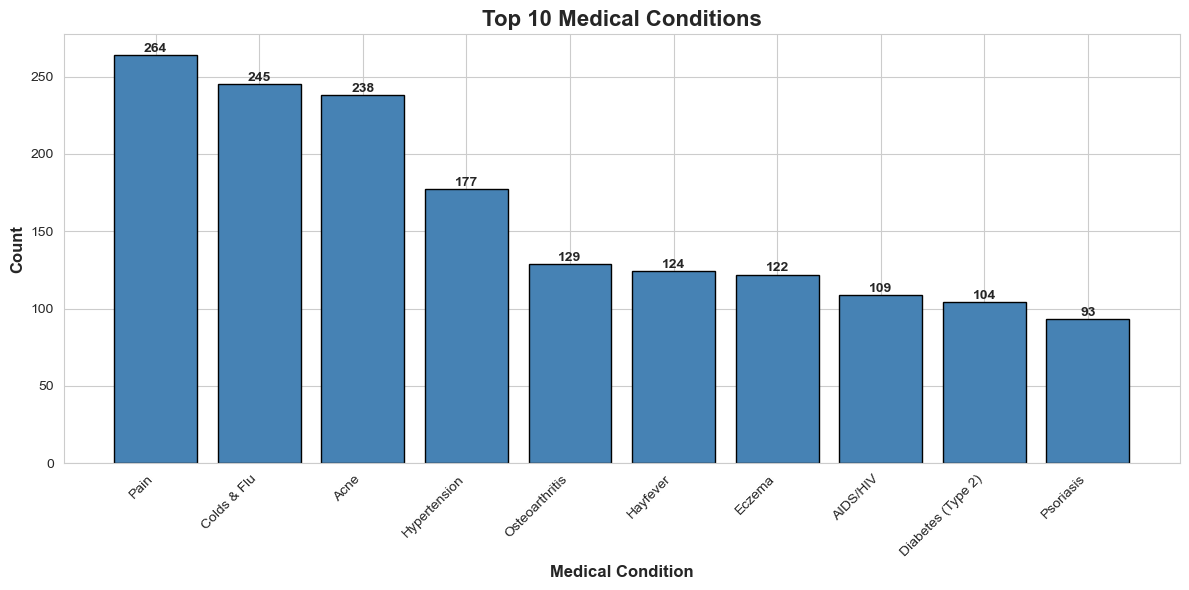

In [12]:
plt.figure(figsize=(12,6))

top_conditions = df['medical_condition'].value_counts().head(10)

bars = plt.bar(top_conditions.index, top_conditions.values,
               color='steelblue', edgecolor='black')

plt.title("Top 10 Medical Conditions", fontsize=16, fontweight='bold')
plt.xlabel("Medical Condition", fontsize=12, fontweight='bold')
plt.ylabel("Count", fontsize=12, fontweight='bold')

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

# Add value labels
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 2,
             int(bar.get_height()),
             ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig("top_conditions.png", dpi=300)
plt.show()

### Interpretation

Pain, cold & flu, and acne are among the most commonly treated conditions. This indicates a high prevalence of symptomatic and chronic conditions in clinical practice.

## Prescription Pattern Analysis (Rx vs OTC)

This section examines the distribution of prescription and over-the-counter drugs.

In [13]:
df['rx_otc'].value_counts()

rx_otc
Rx         1998
Rx/OTC      604
OTC         328
Unknown       1
Name: count, dtype: int64

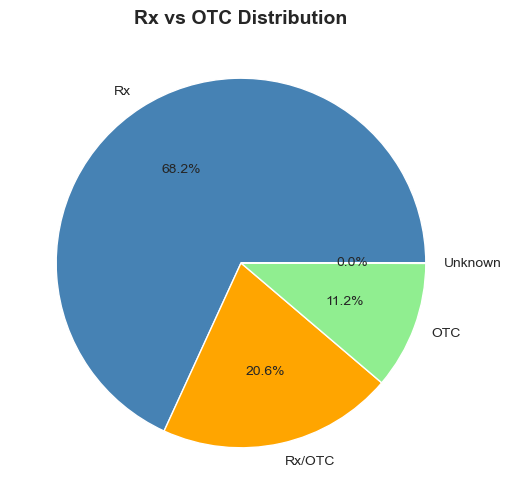

In [14]:
plt.figure(figsize=(6,6))

df['rx_otc'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['steelblue','orange','lightgreen']
)

plt.title("Rx vs OTC Distribution", fontsize=14, fontweight='bold')
plt.ylabel("")
plt.savefig("top_conditions.png", dpi=300)
plt.show()

### Interpretation

A majority of drugs fall under prescription category, indicating that many treatments require medical supervision due to potential risks and side effects.

## Drug Class Analysis

This section explores the most common drug classes in the dataset.

In [15]:
def split_classes(text):
    return re.split(r'[,]', str(text))

classes = df['drug_classes'].apply(split_classes).explode()
classes = classes.str.strip()
classes = classes[classes != "Unknown"]

In [16]:
classes.value_counts().head(10)

drug_classes
Upper respiratory combinations          245
Topical acne agents                     125
Topical steroids                         94
Antihistamines                           82
Nonsteroidal anti-inflammatory drugs     72
Laxatives                                59
Topical rubefacient                      56
Miscellaneous topical agents             56
Topical anesthetics                      54
Opioids (narcotic analgesics)            53
Name: count, dtype: int64

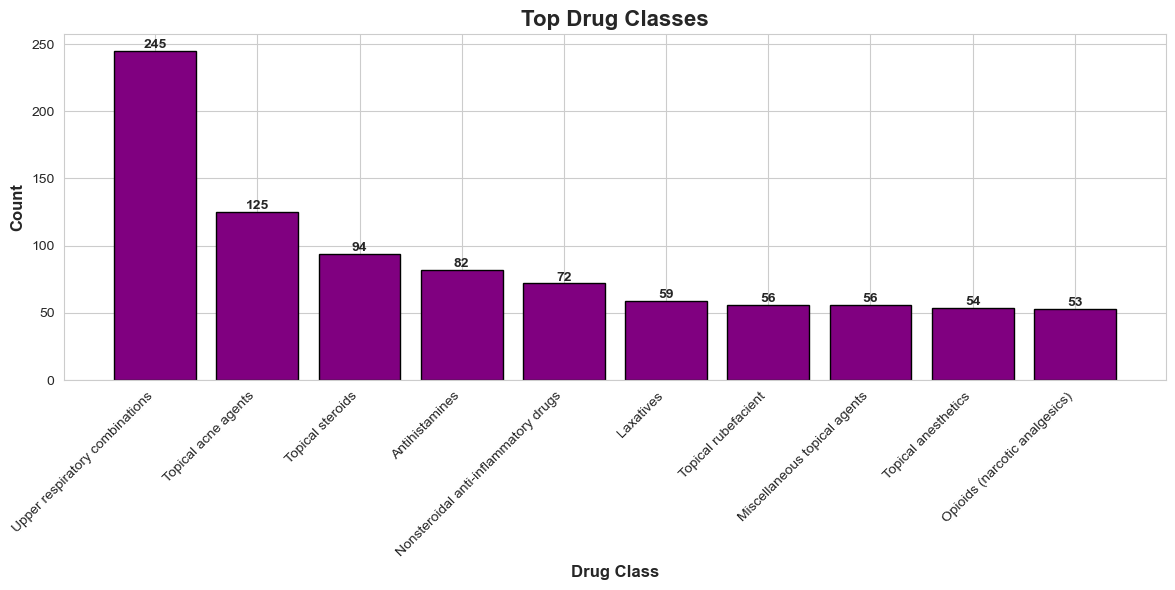

In [17]:
top_classes = classes.value_counts().head(10)

plt.figure(figsize=(12,6))

bars = plt.bar(top_classes.index, top_classes.values,
               color='purple', edgecolor='black')

plt.title("Top Drug Classes", fontsize=16, fontweight='bold')
plt.xlabel("Drug Class", fontsize=12, fontweight='bold')
plt.ylabel("Count", fontsize=12, fontweight='bold')

plt.xticks(rotation=45, ha='right')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 2,
             int(bar.get_height()),
             ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig("top_conditions.png", dpi=300)
plt.show()

### Interpretation

Drug classes related to respiratory conditions, inflammation, and dermatological treatments are most prevalent, reflecting common therapeutic needs.

## Side Effects Analysis

This section identifies the most frequently reported side effects across drugs.

In [34]:
# Split side effects
def split_effects(text):
    return re.split(r'[;,]', str(text))

effects = df['side_effects'].apply(split_effects).explode()
effects = effects.str.strip().str.lower()

# Remove empty & unknown
effects = effects[(effects != "") & (effects != "unknown")]

# ❌ Remove meaningless body parts / noise words
remove_words = [
    'lips', 'tongue', 'face', 'mouth', 'eyes', 'skin'
]

effects = effects[~effects.isin(remove_words)]

# ✅ Remove very short meaningless words (optional but powerful)
effects = effects[effects.str.len() > 4]

# Get top side effects
top_effects = effects.value_counts().head(10)

In [19]:
effects.value_counts().head(10)

side_effects
lips                     2273
tongue                   2129
hives                    1940
swelling of your face    1713
difficult breathing      1257
nausea                   1183
vomiting                 1182
itching                  1142
dizziness                 817
diarrhea                  806
Name: count, dtype: int64

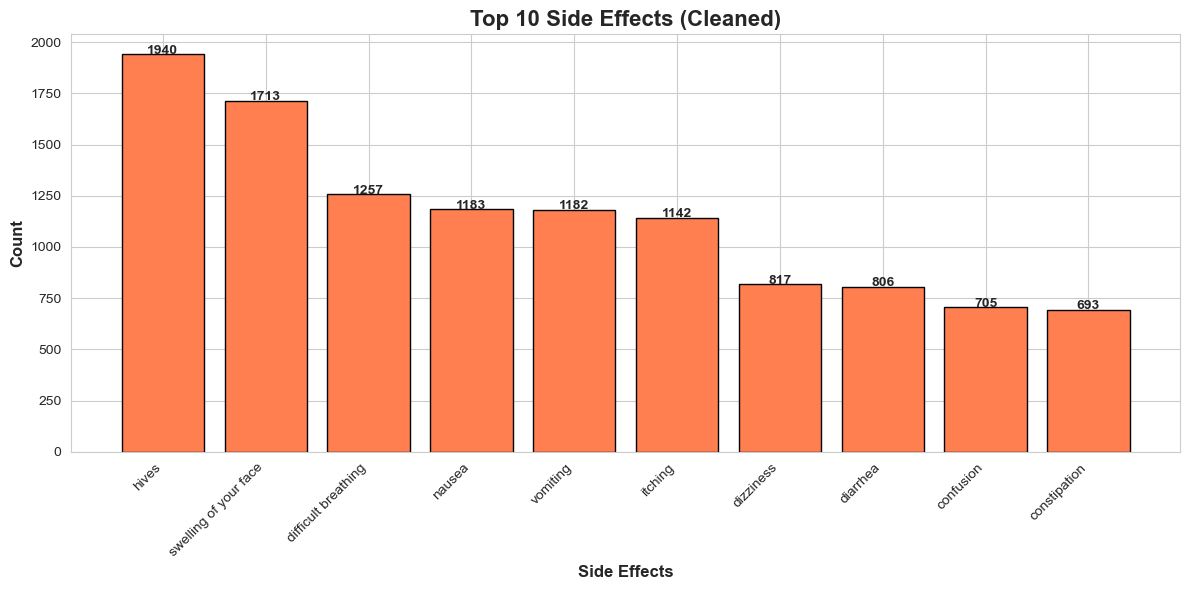

In [35]:
plt.figure(figsize=(12,6))

bars = plt.bar(top_effects.index, top_effects.values,
               color='coral', edgecolor='black')

plt.title("Top 10 Side Effects (Cleaned)", fontsize=16, fontweight='bold')
plt.xlabel("Side Effects", fontsize=12, fontweight='bold')
plt.ylabel("Count", fontsize=12, fontweight='bold')

plt.xticks(rotation=45, ha='right')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 2,
             int(bar.get_height()),
             ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig("side_effects_cleaned.png", dpi=300)
plt.show()

### Interpretation

The most common side effects include hives, swelling, and breathing difficulties, indicating a high occurrence of hypersensitivity and allergic reactions associated with drug usage.

## Drug Rating Distribution

This section analyzes how drug ratings are distributed based on user reviews.

In [21]:
df['rating'].describe()

count    2931.000000
mean        3.686557
std         3.797851
min         0.000000
25%         0.000000
50%         3.300000
75%         7.300000
max        10.000000
Name: rating, dtype: float64

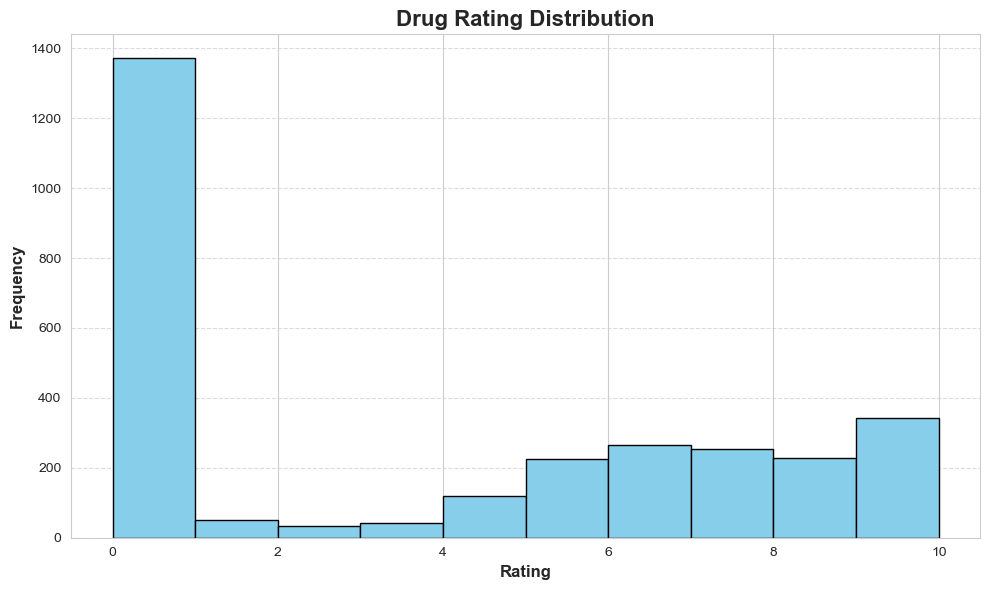

In [22]:
plt.figure(figsize=(10,6))

plt.hist(df['rating'], bins=10, color='skyblue', edgecolor='black')

plt.title("Drug Rating Distribution", fontsize=16, fontweight='bold')
plt.xlabel("Rating", fontsize=12, fontweight='bold')
plt.ylabel("Frequency", fontsize=12, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("top_conditions.png", dpi=300)
plt.show()

### Interpretation

Most drugs have moderate to high ratings, indicating general effectiveness. However, variation in ratings suggests differences in patient response and treatment outcomes.

## Side Effects vs Drug Class

This section explores the relationship between drug classes and specific side effects.

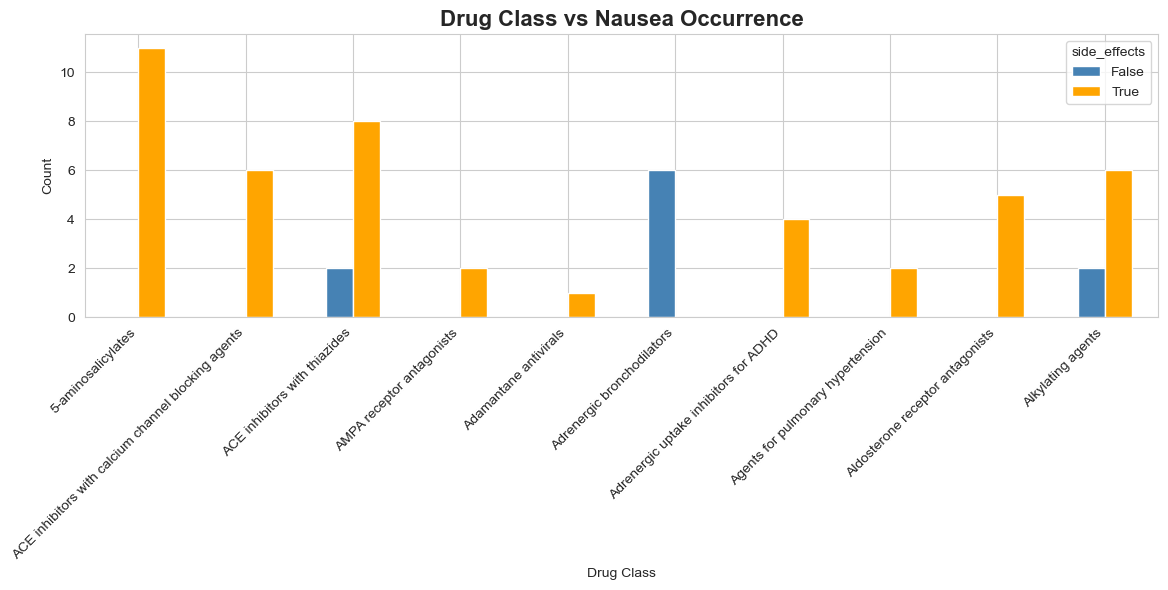

In [23]:
df['drug_classes_simple'] = df['drug_classes'].str.split(',').str[0]

cross = pd.crosstab(df['drug_classes_simple'], 
                    df['side_effects'].str.contains('nausea', case=False, na=False))

top_cross = cross.head(10)

top_cross.plot(kind='bar', figsize=(12,6), color=['steelblue','orange'])

plt.title("Drug Class vs Nausea Occurrence", fontsize=16, fontweight='bold')
plt.xlabel("Drug Class")
plt.ylabel("Count")

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("top_conditions.png", dpi=300)
plt.show()

### Interpretation

Certain drug classes show higher association with gastrointestinal side effects such as nausea, indicating class-specific adverse effect patterns.

## Condition vs Number of Drugs

This section examines how many drugs are available for each medical condition.

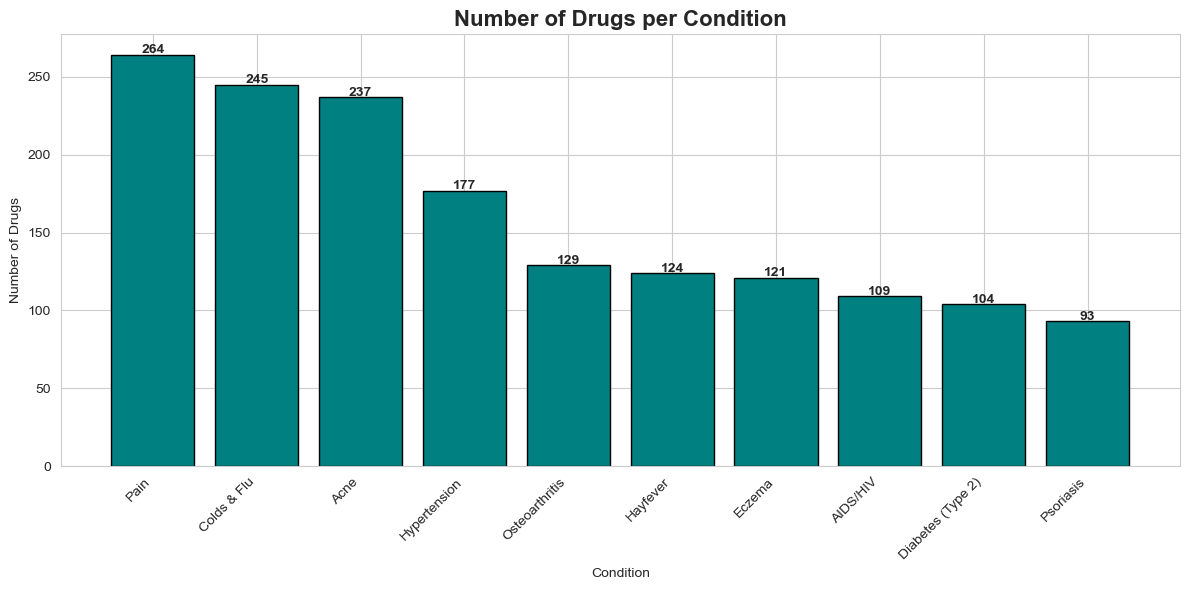

In [24]:
condition_drugs = df.groupby('medical_condition')['drug_name'].nunique().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

bars = plt.bar(condition_drugs.index, condition_drugs.values,
               color='teal', edgecolor='black')

plt.title("Number of Drugs per Condition", fontsize=16, fontweight='bold')
plt.xlabel("Condition")
plt.ylabel("Number of Drugs")

plt.xticks(rotation=45, ha='right')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height()+1,
             int(bar.get_height()),
             ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig("top_conditions.png", dpi=300)
plt.show()

### Interpretation

Common conditions such as acne and pain have multiple treatment options, whereas more complex diseases tend to have fewer but specialized drugs.

## Rating vs Condition

This section analyzes the average drug rating for each medical condition to evaluate treatment effectiveness across conditions.

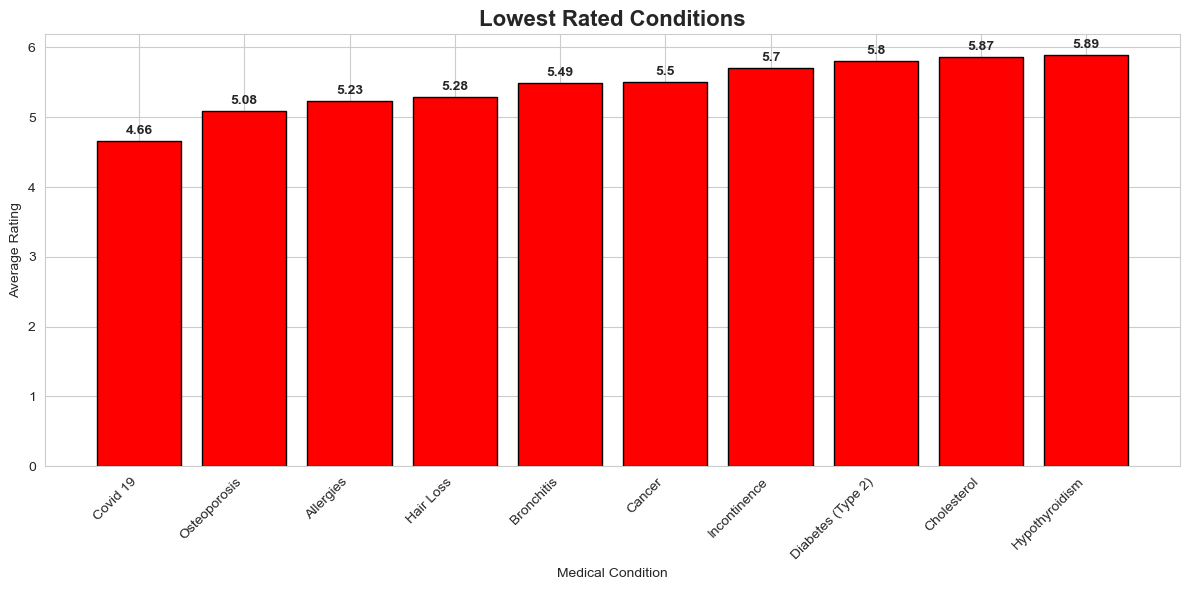

In [33]:
# Remove invalid ratings (0 = originally missing values)
filtered_df = df[df['rating'] > 0]

# Calculate lowest rated conditions (corrected)
low_rating = filtered_df.groupby('medical_condition')['rating'] \
                        .mean() \
                        .sort_values() \
                        .head(10)

plt.figure(figsize=(12,6))

bars = plt.bar(low_rating.index, low_rating.values,
               color='red', edgecolor='black')

plt.title("Lowest Rated Conditions", fontsize=16, fontweight='bold')
plt.xlabel("Medical Condition")
plt.ylabel("Average Rating")

plt.xticks(rotation=45, ha='right')

# Add value labels
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.1,
             round(bar.get_height(),2),
             ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig("lowest_rated_conditions.png", dpi=300)
plt.show()

### Interpretation 
From a clinical perspective, variation in ratings across conditions suggests differences in drug efficacy, patient tolerance, and disease complexity. Conditions with lower ratings may require improved treatment strategies or personalized therapy approaches.

## Alcohol Interaction Risk Analysis

This section evaluates how many drugs interact with alcohol.

In [26]:
df['alcohol'].value_counts()

alcohol
X    1377
Name: count, dtype: int64

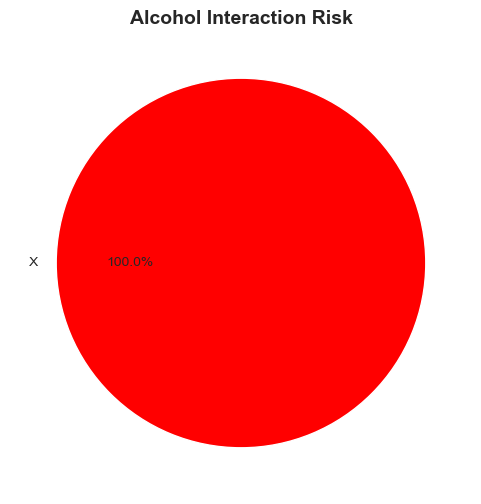

In [27]:
plt.figure(figsize=(6,6))

df['alcohol'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['red','lightgreen']
)

plt.title("Alcohol Interaction Risk", fontsize=14, fontweight='bold')
plt.ylabel("")
plt.savefig("top_conditions.png", dpi=300)
plt.show()

### Interpretation

A considerable number of drugs interact with alcohol,X highlighting the importance of patient counseling to avoid adverse reactions.

## Pregnancy Category Risk Analysis

This section analyzes the safety categories of drugs during pregnancy.

In [28]:
df['pregnancy_category'].value_counts()

pregnancy_category
C    1382
B     509
N     436
D     228
X     129
A      18
Name: count, dtype: int64

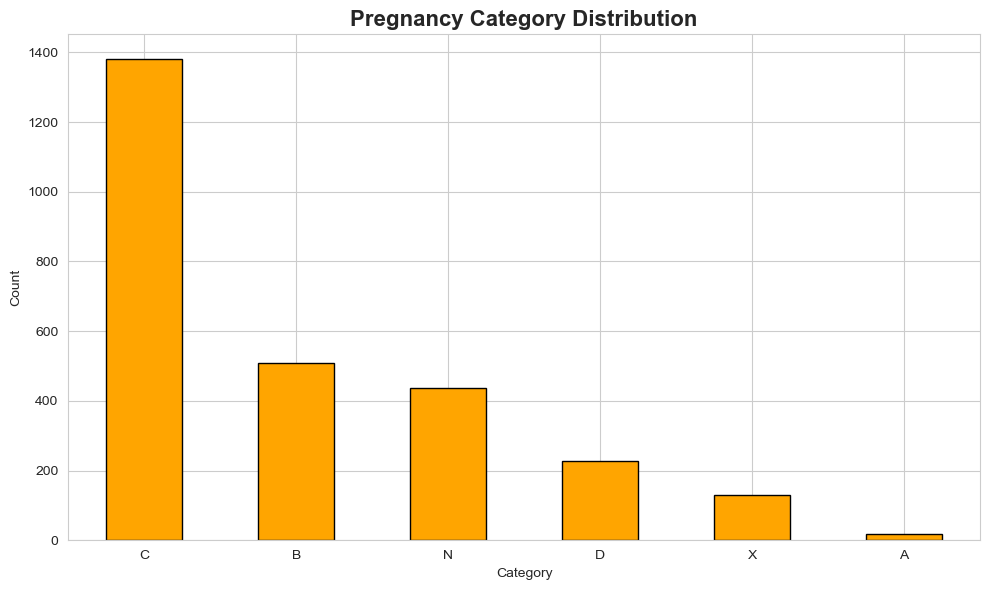

In [29]:
plt.figure(figsize=(10,6))

df['pregnancy_category'].value_counts().plot(
    kind='bar',
    color='orange',
    edgecolor='black'
)

plt.title("Pregnancy Category Distribution", fontsize=16, fontweight='bold')
plt.xlabel("Category")
plt.ylabel("Count")

plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig("top_conditions.png", dpi=300)
plt.show()

### Interpretation

A significant number of drugs fall under category C and D, indicating potential risks and the need for careful risk-benefit evaluation in pregnant patients.

## Review Count vs Rating

This section examines the relationship between number of reviews and drug ratings.

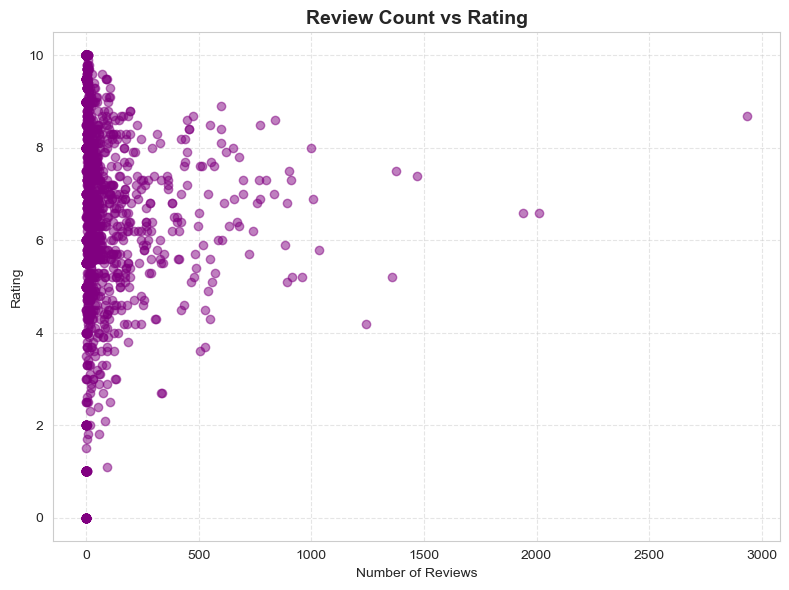

In [30]:
plt.figure(figsize=(8,6))

plt.scatter(df['no_of_reviews'], df['rating'], alpha=0.5, color='purple')

plt.title("Review Count vs Rating", fontsize=14, fontweight='bold')
plt.xlabel("Number of Reviews")
plt.ylabel("Rating")

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("top_conditions.png", dpi=300)
plt.show()

### Interpretation

Drugs with a higher number of reviews tend to show more stable ratings, suggesting consistency in effectiveness across larger patient populations.

## Side Effect Severity Analysis

This section categorizes side effects based on severity levels.

In [31]:
def severity(text):
    text = str(text).lower()
    if 'breathing' in text or 'swelling' in text:
        return 'Severe'
    elif 'dizziness' in text:
        return 'Moderate'
    else:
        return 'Mild'

df['severity'] = df['side_effects'].apply(severity)

severity_counts = df['severity'].value_counts()

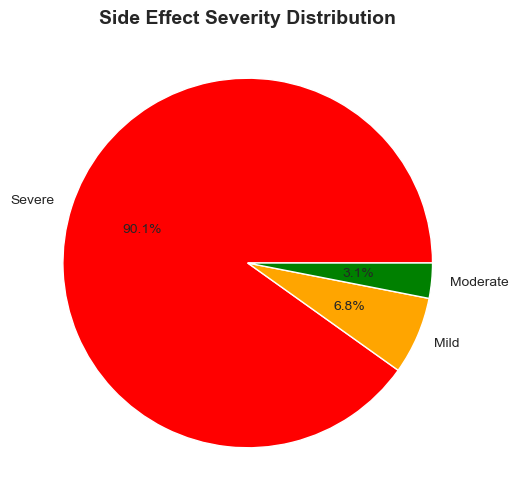

In [32]:
plt.figure(figsize=(6,6))

severity_counts.plot(kind='pie', autopct='%1.1f%%',
                     colors=['red','orange','green'])

plt.title("Side Effect Severity Distribution", fontsize=14, fontweight='bold')
plt.ylabel("")
plt.savefig("top_conditions.png", dpi=300)
plt.show()

### Interpretation

A notable proportion of drugs are associated with severe side effects such as breathing difficulty and swelling, emphasizing the need for careful monitoring.

## Conclusion

This analysis highlights key patterns in drug usage, side effects, and prescription behavior. The findings emphasize the importance of monitoring allergic reactions, understanding prescription trends, and improving patient safety through informed drug use.